## adding tracks 

In [9]:
import csv

DS = 5.0

def add_section(writer, length, curvature):
    n = int(length / DS)
    for _ in range(n):
        writer.writerow({"ds": DS, "curvature": curvature})

with open("tracks/silverstone.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["ds", "curvature"])
    writer.writeheader()

    # Hamilton Straight
    add_section(writer, 770, 0.000)

    # Abbey
    add_section(writer, 150, 0.0067)

    # Farm Straight
    add_section(writer, 300, 0.000)

    # Village
    add_section(writer, 120, 0.0167)

    # Loop
    add_section(writer, 90, 0.0286)

    # Wellington Straight
    add_section(writer, 700, 0.000)

    # Brooklands
    add_section(writer, 180, 0.0060)

    # Luffield
    add_section(writer, 300, 0.0100)

    # Copse
    add_section(writer, 180, 0.0056)

    # Maggotts–Becketts–Chapel
    add_section(writer, 450, 0.0111)

    # Hangar Straight
    add_section(writer, 770, 0.000)

    # Stowe
    add_section(writer, 200, 0.0050)

    # Vale + Club
    add_section(writer, 400, 0.0120)


In [2]:
import math

# -----------------------------
# Track definition
# -----------------------------

class TrackSegment:
    def __init__(self, ds, curvature):
        self.ds = ds              # segment length (m)
        self.curvature = curvature  # 1/radius (1/m)


def build_track():
    """
    Simple track:
    - Straight
    - Straight
    - Corner
    - Corner
    - Straight
    """
    ds = 10.0  # meters per segment

    return [
        TrackSegment(ds, 0.0),
        TrackSegment(ds, 0.0),
        TrackSegment(ds, 0.10),
        TrackSegment(ds, 0.10),
        TrackSegment(ds, 0.0),
    ]


# -----------------------------
# Vehicle definition
# -----------------------------

class Vehicle:
    def __init__(self):
        self.mu = 1.2          # tire friction coefficient
        self.g = 9.81          # gravity (m/s^2)
        self.accel = 4.0       # acceleration (m/s^2)
        self.brake = 8.0       # braking (m/s^2)


# -----------------------------
# Physics functions
# -----------------------------

def lateral_speed_limit(mu, g, curvature):
    if curvature == 0.0:
        return float("inf")
    return math.sqrt(mu * g / curvature)


class F1Team:
    def __init__(self, name, mu, accel, brake):
        self.name = name
        self.mu = mu              # tire friction coefficient
        self.accel = accel        # acceleration (m/s^2)
        self.brake = brake        # braking (m/s^2)


def get_team_vehicle(team_name):
    """Returns a Vehicle with team-specific qualifying setup"""
    teams = {
        "mercedes": Vehicle.__new__(Vehicle),
        "redbull": Vehicle.__new__(Vehicle),
        "mclaren": Vehicle.__new__(Vehicle),
    }
    
    # Qualifying setups (optimized for speed)
    teams["mercedes"].__dict__ = {"mu": 1.35, "g": 9.81, "accel": 4.5, "brake": 9.0}
    teams["redbull"].__dict__ = {"mu": 1.30, "g": 9.81, "accel": 4.6, "brake": 8.8}
    teams["mclaren"].__dict__ = {"mu": 1.28, "g": 9.81, "accel": 4.3, "brake": 8.5}
    
    return teams.get(team_name.lower(), Vehicle())


# -----------------------------
# Lap time simulation
# -----------------------------

def simulate_lap(track, vehicle):
    n = len(track)
    v = [0.0] * n  # speed at each segment start

    # ---- Forward pass (acceleration) ----
    for i in range(n - 1):
        ds = track[i].ds
        v_possible = math.sqrt(v[i] ** 2 + 2 * vehicle.accel * ds)

        v_lat = lateral_speed_limit(
            vehicle.mu, vehicle.g, track[i + 1].curvature
        )

        v[i + 1] = min(v_possible, v_lat)

    # ---- Backward pass (braking) ----
    for i in reversed(range(n - 1)):
        ds = track[i].ds
        v_allowed = math.sqrt(v[i + 1] ** 2 + 2 * vehicle.brake * ds)
        v[i] = min(v[i], v_allowed)

    # ---- Lap time integration ----
    lap_time = 0.0
    for i in range(1, n):
        lap_time += track[i - 1].ds / v[i]

    return lap_time, v

import csv

def load_track_from_csv(path):
    track = []
    with open(path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track.append(
                TrackSegment(
                    ds=float(row["ds"]),
                    curvature=float(row["curvature"])
                )
            )
    return track

# -----------------------------
# Main
# -----------------------------

if __name__ == "__main__":
    track = load_track_from_csv("tracks/silverstone.csv")
    # track = build_track()
    vehicle = Vehicle()

    lap_time, speeds = simulate_lap(track, vehicle)

    print("Segment speeds (m/s):")
    # Simulate for different teams/drivers
    teams = ["mercedes", "redbull", "mclaren"]
    results = []
    
    for team in teams:
        vehicle = get_team_vehicle(team)
        lap_time, _ = simulate_lap(track, vehicle)
        results.append({"Team": team.capitalize(), "Lap Time": lap_time})
    
    # Sort by lap time and display standings
    results.sort(key=lambda x: x["Lap Time"])
    
    print("QUALIFYING STANDINGS:")
    print("-" * 40)
    for pos, result in enumerate(results, 1):
        print(f"{pos}. {result['Team']:<15} {result['Lap Time']:.2f}s")

    print(f"\nTotal lap time: {lap_time:.2f} seconds")


Segment speeds (m/s):
QUALIFYING STANDINGS:
----------------------------------------
1. Mercedes        109.08s
2. Redbull         110.21s
3. Mclaren         111.92s

Total lap time: 111.92 seconds


Track length: 4610.0 m
Min speed: 0.00 m/s
Max speed: 74.97 m/s
Total lap time: 115.70 seconds


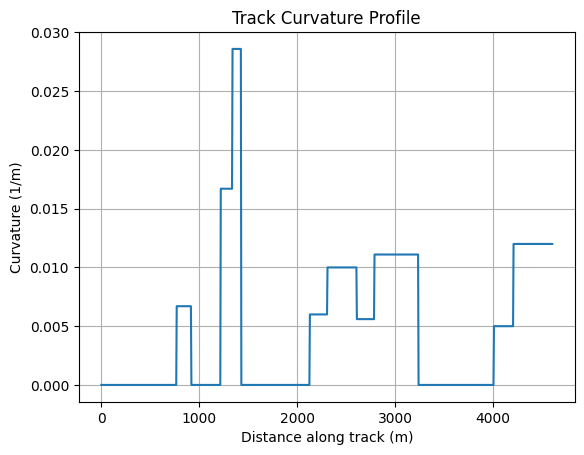

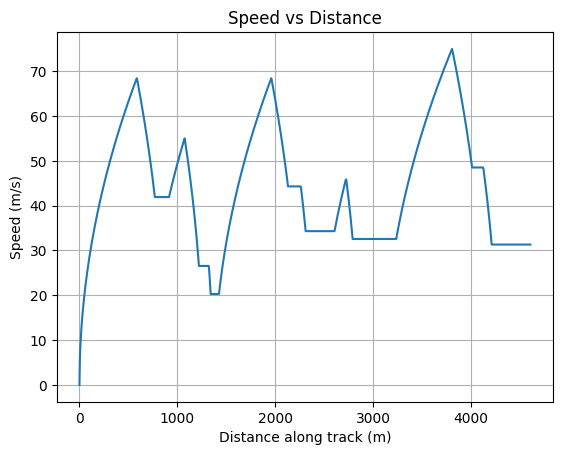

In [7]:
import math
import csv
import matplotlib.pyplot as plt

# -----------------------------
# Track definition
# -----------------------------

class TrackSegment:
    def __init__(self, ds, curvature):
        self.ds = ds              # segment length (m)
        self.curvature = curvature  # 1/radius (1/m)


def build_track():
    ds = 10.0
    return [
        TrackSegment(ds, 0.0),
        TrackSegment(ds, 0.0),
        TrackSegment(ds, 0.10),
        TrackSegment(ds, 0.10),
        TrackSegment(ds, 0.0),
    ]


# -----------------------------
# Vehicle definition
# -----------------------------

class Vehicle:
    def __init__(self):
        self.mu = 1.2
        self.g = 9.81
        self.accel = 4.0
        self.brake = 8.0


# -----------------------------
# Physics functions
# -----------------------------

def lateral_speed_limit(mu, g, curvature):
    if curvature == 0.0:
        return float("inf")
    return math.sqrt(mu * g / curvature)


# -----------------------------
# Lap time simulation
# -----------------------------

def simulate_lap(track, vehicle):
    n = len(track)
    v = [0.0] * n

    # Forward pass
    for i in range(n - 1):
        ds = track[i].ds
        v_possible = math.sqrt(v[i] ** 2 + 2 * vehicle.accel * ds)
        v_lat = lateral_speed_limit(
            vehicle.mu, vehicle.g, track[i + 1].curvature
        )
        v[i + 1] = min(v_possible, v_lat)

    # Backward pass
    for i in reversed(range(n - 1)):
        ds = track[i].ds
        v_allowed = math.sqrt(v[i + 1] ** 2 + 2 * vehicle.brake * ds)
        v[i] = min(v[i], v_allowed)

    # Lap time
    lap_time = 0.0
    for i in range(1, n):
        lap_time += track[i - 1].ds / v[i]

    return lap_time, v


# -----------------------------
# Track loading
# -----------------------------

def load_track_from_csv(path):
    track = []
    with open(path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            track.append(
                TrackSegment(
                    ds=float(row["ds"]),
                    curvature=float(row["curvature"])
                )
            )
    return track


# -----------------------------
# Plotting utilities
# -----------------------------

def build_distance_axis(track):
    distance = [0.0]
    for seg in track:
        distance.append(distance[-1] + seg.ds)
    return distance[:-1]


def plot_curvature(track):
    distance = build_distance_axis(track)
    curvature = [seg.curvature for seg in track]

    plt.figure()
    plt.plot(distance, curvature)
    plt.xlabel("Distance along track (m)")
    plt.ylabel("Curvature (1/m)")
    plt.title("Track Curvature Profile")
    plt.grid(True)
    plt.show()


def plot_speed(track, speeds):
    distance = build_distance_axis(track)

    plt.figure()
    plt.plot(distance, speeds)
    plt.xlabel("Distance along track (m)")
    plt.ylabel("Speed (m/s)")
    plt.title("Speed vs Distance")
    plt.grid(True)
    plt.show()


# -----------------------------
# Main
# -----------------------------

if __name__ == "__main__":
    track = load_track_from_csv("tracks/silverstone.csv")
    vehicle = Vehicle()

    lap_time, speeds = simulate_lap(track, vehicle)

    print(f"Track length: {sum(seg.ds for seg in track):.1f} m")
    print(f"Min speed: {min(speeds):.2f} m/s")
    print(f"Max speed: {max(speeds):.2f} m/s")
    print(f"Total lap time: {lap_time:.2f} seconds")

    plot_curvature(track)
    plot_speed(track, speeds)


#### make it account for tyre temperatures
#### grip with downforce 

In [5]:
import math

# Function to calculate grip based on tyre temperature
def tyre_grip(temperature):
    """
    Calculate the grip coefficient based on tyre temperature.
    Optimal temperature range: 80-100°C
    """
    if temperature < 80:
        return 0.8 + 0.005 * (temperature - 20)  # Grip increases as temperature rises to optimal range
    elif 80 <= temperature <= 100:
        return 1.0  # Optimal grip
    else:
        return 1.0 - 0.01 * (temperature - 100)  # Grip decreases as temperature exceeds optimal range

# Modify the simulate_lap function to include tyre temperature effects
def simulate_lap_with_temperature(track, vehicle, initial_temp=80):
    n = len(track)
    v = [0.0] * n  # Speed at each segment start
    tyre_temp = initial_temp  # Initial tyre temperature

    # ---- Forward pass (acceleration) ----
    for i in range(n - 1):
        ds = track[i].ds
        grip = tyre_grip(tyre_temp)
        v_possible = math.sqrt(v[i] ** 2 + 2 * vehicle.accel * grip * ds)

        v_lat = lateral_speed_limit(
            vehicle.mu * grip, vehicle.g, track[i + 1].curvature
        )

        v[i + 1] = min(v_possible, v_lat)

        # Update tyre temperature (simplified model)
        tyre_temp += 0.1 * (v[i + 1] - v[i])  # Temperature increases with speed changes

    # ---- Backward pass (braking) ----
    for i in reversed(range(n - 1)):
        ds = track[i].ds
        grip = tyre_grip(tyre_temp)
        v_allowed = math.sqrt(v[i + 1] ** 2 + 2 * vehicle.brake * grip * ds)
        v[i] = min(v[i], v_allowed)

        # Update tyre temperature (simplified model)
        tyre_temp -= 0.05 * (v[i + 1] - v[i])  # Temperature decreases with braking

    # ---- Lap time integration ----
    lap_time = 0.0
    for i in range(1, n):
        lap_time += track[i - 1].ds / v[i]

    return lap_time, v

In [ ]:
if __name__ == "__main__":
    track = load_track_from_csv("tracks/silverstone.csv")

    # Simulate lap with tyre temperature effects
    vehicle = Vehicle()
    lap_time, speeds = simulate_lap_with_temperature(track, vehicle)

    print(f"Track length: {sum(seg.ds for seg in track):.1f} m")
    print(f"Min speed: {min(speeds):.2f} m/s")
    print(f"Max speed: {max(speeds):.2f} m/s")
    print(f"Total lap time: {lap_time:.2f} seconds")

    # Simulate for different teams/drivers with tyre temperature effects
    teams = ["mercedes", "redbull", "mclaren"]
    results = []

    for team in teams:
        vehicle = get_team_vehicle(team)
        lap_time, _ = simulate_lap_with_temperature(track, vehicle)
        results.append({"Team": team.capitalize(), "Lap Time": lap_time})

    # Sort by lap time and display standings
    results.sort(key=lambda x: x["Lap Time"])

    print("\nQUALIFYING STANDINGS:")
    print("-" * 40)
    for pos, result in enumerate(results, 1):
        print(f"{pos}. {result['Team']:<15} {result['Lap Time']:.2f}s")

    # Plot results
    plot_curvature(track)
    plot_speed(track, speeds)